# Project

## Loading the dataset

In [1]:
import glob
from typing import Tuple
import polars as pl
import pandas as pd
import os

In [2]:
DATA_ROOT = "data"

In [3]:
def get_labels_from_filename(filename: str) -> Tuple[str, str, bool]:
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False  # Should never reach here with correct dataset format

In [4]:
def combine_dataset_files(root: str, save_name: str = "combined_dataset") -> None:
    path = os.path.join(root,"*","*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [5]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_ROOT, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_ROOT, save_name)
    df = pl.read_parquet(path)
    return df

In [6]:
df = load_dataset("combined_dataset").with_columns(pl.col(pl.Float64).cast(pl.Float32)) # reducing memory usage

## Exploratory Data Analysis

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [9]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Name", y="len", data= attack_counts, ax=ax)
    ax.set_title("Distribution of Attack Names (Entire Dataset)")
    ax.set_xlabel("Attack Name")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_603913/3936347908.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


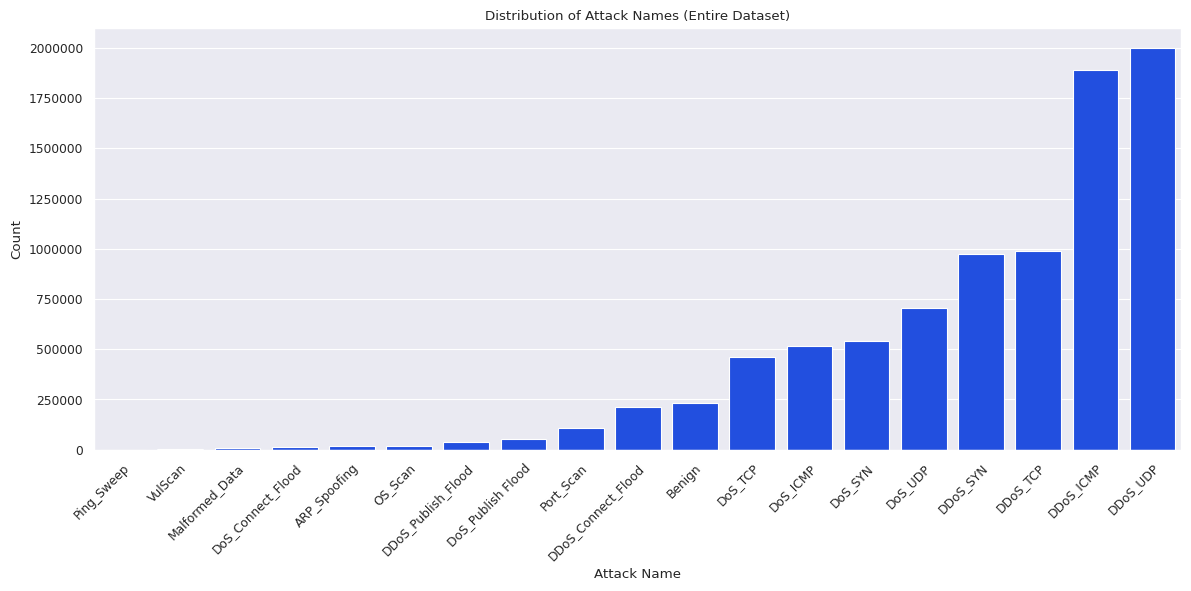

In [10]:
plot_attack_counts(df)

In [11]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    data = ddos_dos_counts.to_pandas()
    data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Attack Type", y="Count", data=data, ax=ax)
    ax.set_title("Distribution of DDoS and DoS Attacks (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_603913/1326252802.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


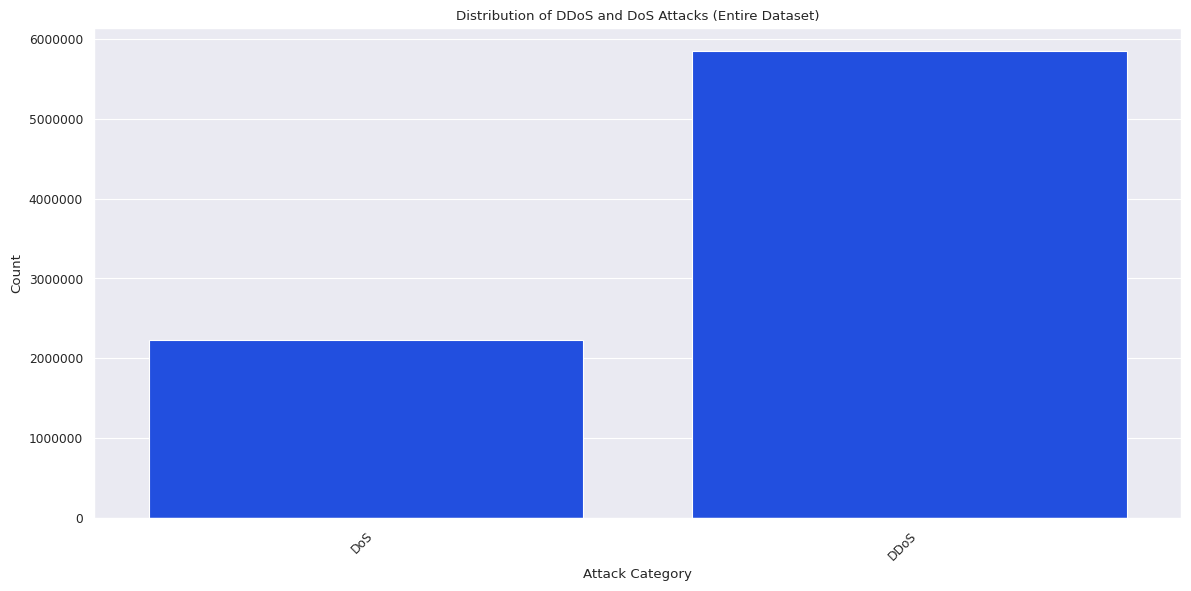

In [12]:
plot_ddos_dos_bar(df)

In [13]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    data = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    ).to_pandas()

    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Excluding DDoS and DoS) (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_603913/2949990234.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


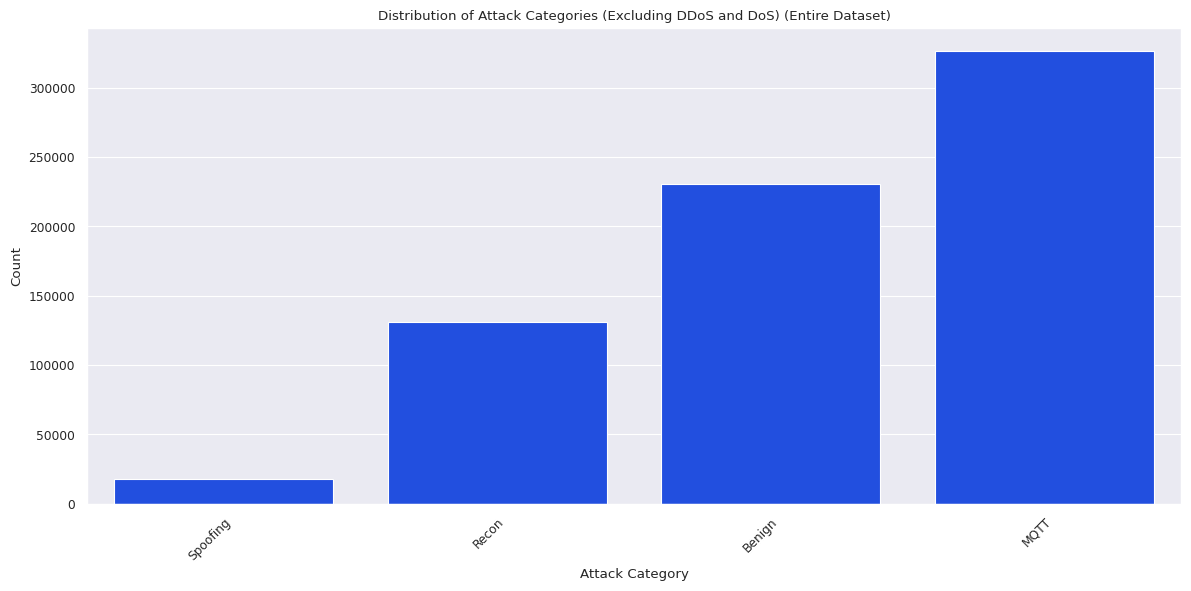

In [14]:
plot_categories_no_ddos_dos(df)

In [15]:
def plot_all_attack_categories_bar(data):
    data = data.group_by("Category").len().sort("len", descending=False).to_pandas()
    fig, ax = plt.subplots(figsize = (12,6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation = 45,
        horizontalalignment="right",
        rotation_mode = "anchor"
    )

    plt.ticklabel_format(style = "plain", axis = "y")
    plt.tight_layout()

/tmp/ipykernel_603913/1611355591.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


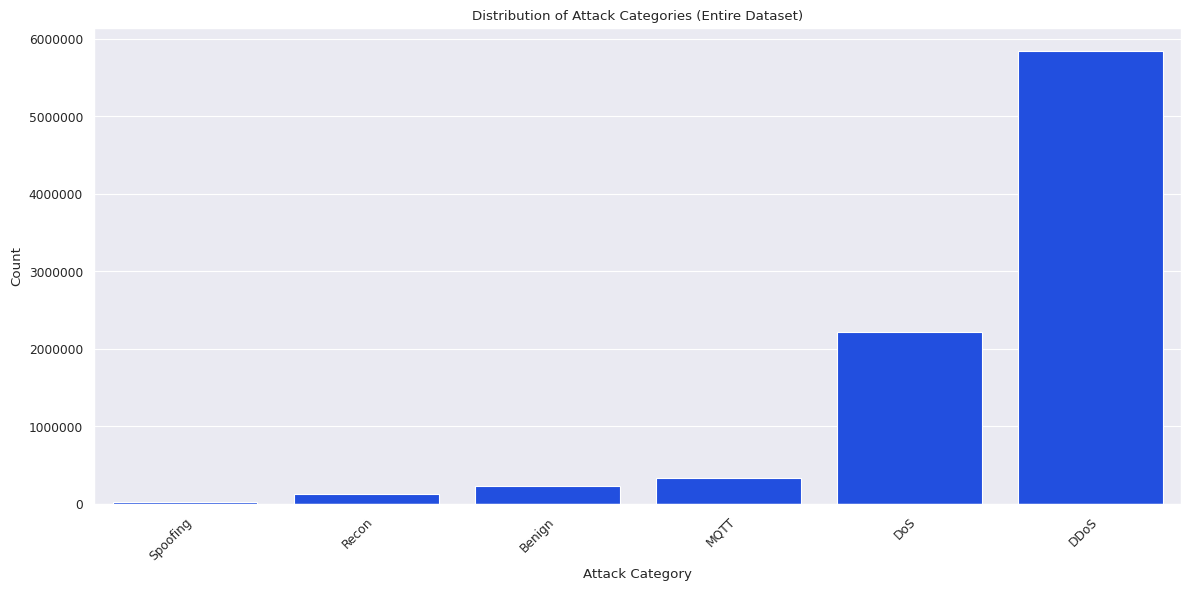

In [16]:
plot_all_attack_categories_bar(df)

In [17]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("tab20c", len(labels))

    fig, ax = plt.subplots()
    ax.set_title("Comparison between Benign and Attack Data (Entire Dataset)")
    plt.pie(
        slices,  # pyright: ignore[reportArgumentType]
        colors=colours,  # pyright: ignore[reportArgumentType]
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

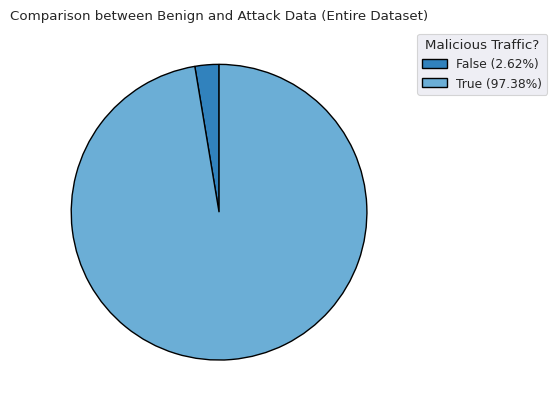

In [18]:
plot_attack_benign_pie(df)

In [19]:
def plot_breakdown_pie(data, title):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    ax.set_title(title)
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,  # pyright: ignore[reportArgumentType]
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)"
        for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

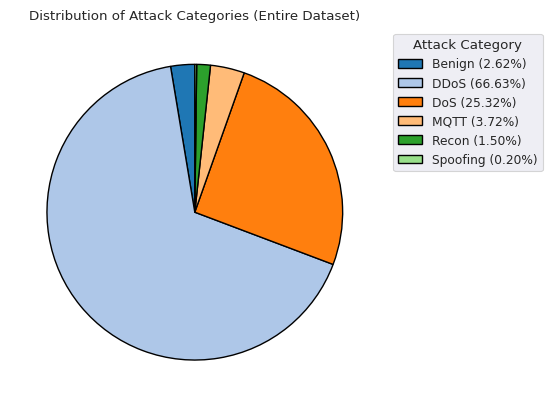

In [20]:
plot_breakdown_pie(df, "Distribution of Attack Categories (Entire Dataset)")

In [21]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws=dict(label="Correlation Coefficient"),
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )

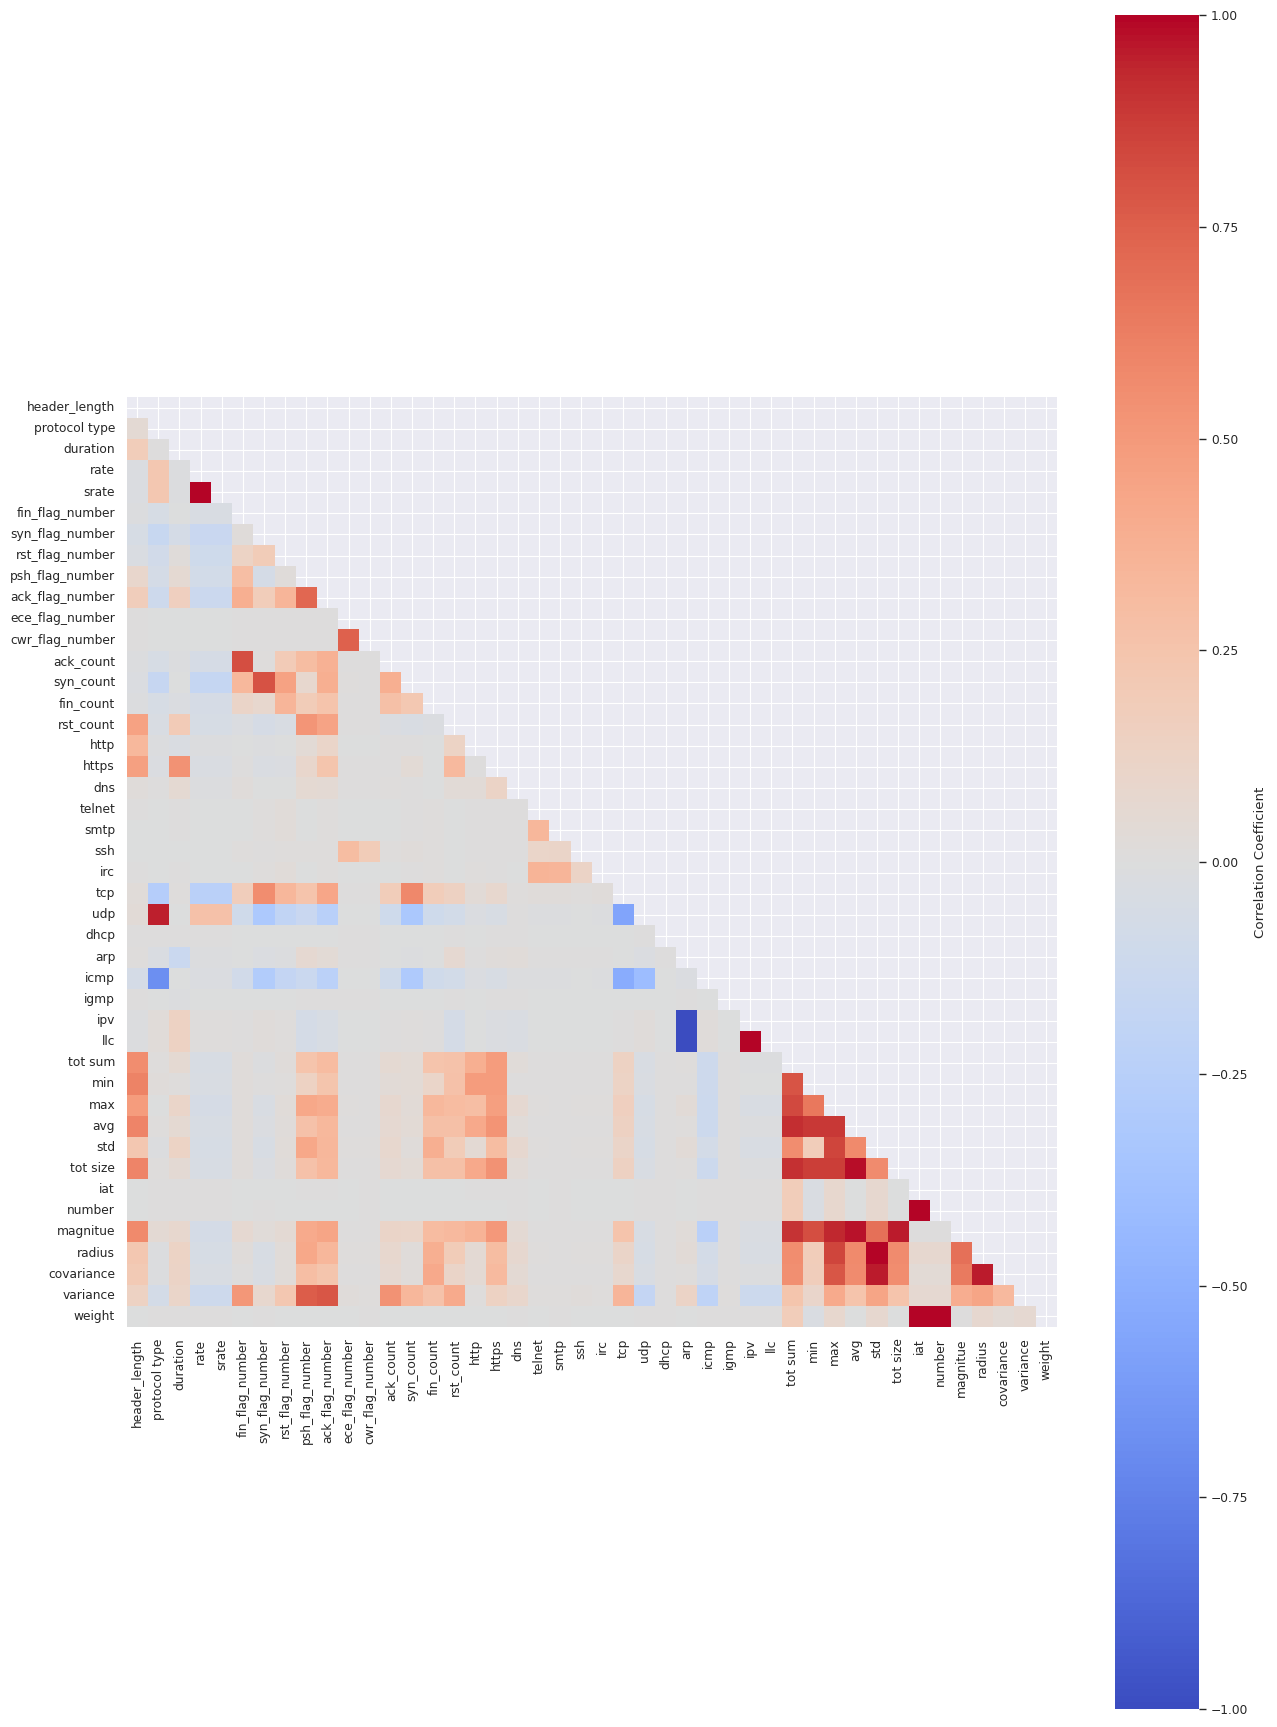

In [22]:
plot_correlation_heatmap(df)

## Preprocessing

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [24]:
df = df.drop(["Name", "Attack"])
X = df.drop("Category").to_numpy()
y = df.select("Category").to_series().to_numpy()

In [25]:
del df

### Splitting Data into Subsets

In [26]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=0, stratify=y_train_val
)

In [27]:
del X, y

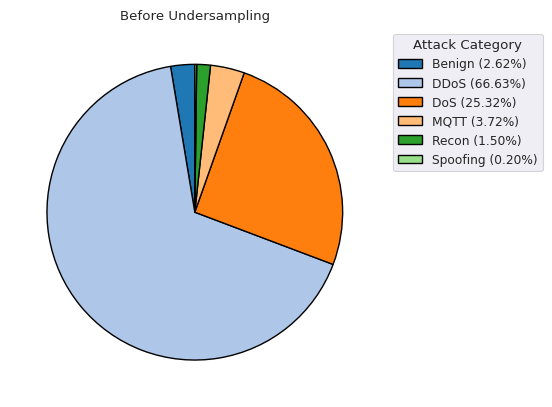

In [28]:
plot_breakdown_pie(pl.DataFrame({"Category": y_train}), "Before Undersampling")

In [29]:
rus = RandomUnderSampler(sampling_strategy={"DDoS": 300_000, "DoS": 300_000}, random_state=0)
X_train, y_train = rus.fit_resample(X_train, y_train)

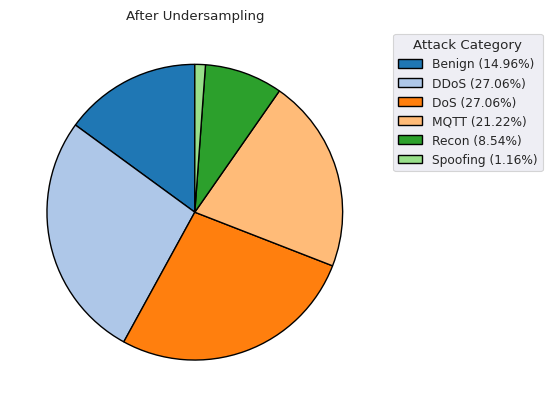

In [30]:
plot_breakdown_pie(pl.DataFrame({"Category": y_train}), "After Undersampling")

### Scaling and Labelling Data

In [ ]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.fit_transform(y_val)
y_test = encoder.fit_transform(y_test)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

In [39]:
scaler.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19',
       'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28',
       'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37',
       'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44'], dtype=object)

### Feature Selection

In [35]:
X_train_df = pd.DataFrame(X_train, columns = scaler.get_feature_names_out())
corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k =1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

In [41]:
to_drop

['x4', 'x30', 'x31', 'x37', 'x39', 'x40', 'x41', 'x42', 'x44']

In [37]:
X_train_df = X_train_df.drop(columns=to_drop)

In [42]:
print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (1108454, 45)
Testing shape: (1755003, 45)
